In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
file_path = "../data/processed/feature_engineered_ev_dataset.csv"

master_df = pd.read_csv(file_path)

In [3]:
features = [
    "ev_stock_lag1",
    "ev_stock_share_lag1",
    "charging_points_lag1"
]

target = "ev_sales_share"

In [5]:
xgb_df = master_df[
    [
        "country",
        "year",
        "ev_stock_lag1",
        "ev_stock_share_lag1",
        "charging_points_lag1",
        "ev_sales_share"
    ]
].dropna().copy()


# Sort observations by country and year

xgb_df = (
    xgb_df
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)


print("XGBoost modelling dataset shape:")

print(
    xgb_df.shape
)


print("\nXGBoost modelling columns:")

print(
    xgb_df.columns.tolist()
)


print("\nMissing values:")

print(
    xgb_df.isnull().sum()
)


print("\nYears available:")

print(
    sorted(
        xgb_df["year"].unique()
    )
)

XGBoost modelling dataset shape:
(499, 6)

XGBoost modelling columns:
['country', 'year', 'ev_stock_lag1', 'ev_stock_share_lag1', 'charging_points_lag1', 'ev_sales_share']

Missing values:
country                 0
year                    0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
ev_sales_share          0
dtype: int64

Years available:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [7]:
xgb_train_df = xgb_df[
    xgb_df["year"] <= 2022
].copy()


xgb_test_df = xgb_df[
    xgb_df["year"].isin(
        [2023, 2024]
    )
].copy()


print("\nTraining dataset shape:")

print(
    xgb_train_df.shape
)


print("\nTesting dataset shape:")

print(
    xgb_test_df.shape
)


print("\nTraining years:")

print(
    sorted(
        xgb_train_df["year"].unique()
    )
)


print("\nTesting years:")

print(
    sorted(
        xgb_test_df["year"].unique()
    )
)


Training dataset shape:
(421, 6)

Testing dataset shape:
(78, 6)

Training years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Testing years:
[np.int64(2023), np.int64(2024)]


In [8]:
X_train = xgb_train_df[
    features
]


y_train = xgb_train_df[
    target
]


X_test = xgb_test_df[
    features
]


y_test = xgb_test_df[
    target
]


print("\nX_train shape:")

print(
    X_train.shape
)


print("\ny_train shape:")

print(
    y_train.shape
)


print("\nX_test shape:")

print(
    X_test.shape
)


print("\ny_test shape:")

print(
    y_test.shape
)



X_train shape:
(421, 3)

y_train shape:
(421,)

X_test shape:
(78, 3)

y_test shape:
(78,)


In [9]:
xgb_model = XGBRegressor(
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test
)

xgb_r2 = r2_score(
    y_test,
    y_pred_xgb
)


xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)


xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)


print("\nXGBoost Results")


print(f"R²   : {xgb_r2:.4f}")


print(f"MAE  : {xgb_mae:.4f}")


print(f"RMSE : {xgb_rmse:.4f}")


XGBoost Results
R²   : 0.7237
MAE  : 7.7718
RMSE : 10.8323


In [10]:
xgb_results = xgb_test_df[
    [
        "country",
        "year"
    ]
].copy()


xgb_results[
    "actual_ev_sales_share"
] = y_test.values


xgb_results[
    "predicted_ev_sales_share"
] = y_pred_xgb


xgb_results[
    "error"
] = (

    xgb_results[
        "actual_ev_sales_share"
    ]

    -

    xgb_results[
        "predicted_ev_sales_share"
    ]

)


xgb_results[
    "absolute_error"
] = (

    xgb_results[
        "error"
    ].abs()

)


print(
    "\nXGBoost Prediction Results:"
)


print(

    xgb_results

    .sort_values(
        "absolute_error",
        ascending=False
    )

    .head(10)

)


XGBoost Prediction Results:
            country  year  actual_ev_sales_share  predicted_ev_sales_share  \
190         Iceland  2024                   42.0                 76.856148   
167         Germany  2024                   19.0                 46.773949   
37          Belgium  2024                   43.0                 69.671715   
91            China  2024                   48.0                 71.727386   
307     Netherlands  2024                   48.0                 71.615311   
494  United Kingdom  2024                   28.0                 48.832275   
321     New Zealand  2024                   11.0                 31.707762   
153          France  2024                   24.0                 40.644474   
125         Denmark  2023                   46.0                 62.642735   
166         Germany  2023                   24.0                 40.464207   

         error  absolute_error  
190 -34.856148       34.856148  
167 -27.773949       27.773949  
37  -26.67171

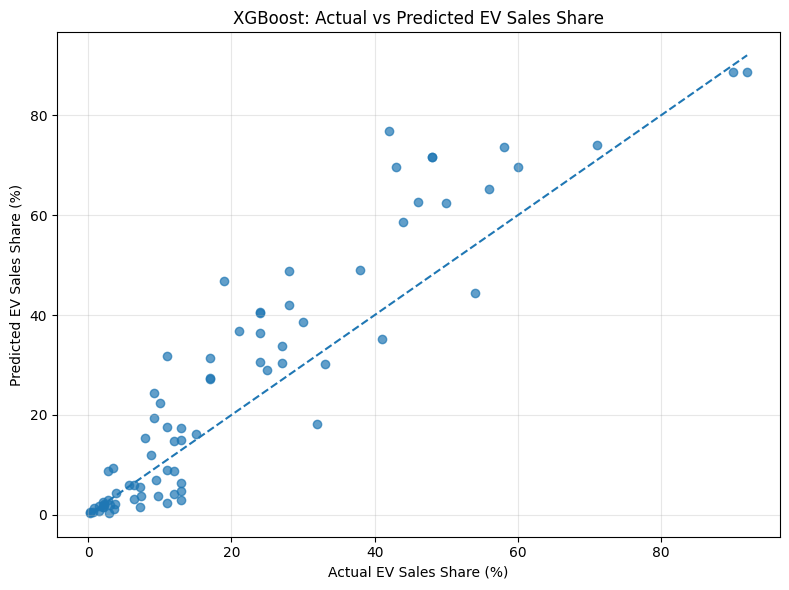

In [17]:
plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.7
)


min_value = min(
    y_test.min(),
    y_pred_xgb.min()
)


max_value = max(
    y_test.max(),
    y_pred_xgb.max()
)


plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)


plt.xlabel(
    "Actual EV Sales Share (%)"
)


plt.ylabel(
    "Predicted EV Sales Share (%)"
)


plt.title(
    "XGBoost: Actual vs Predicted EV Sales Share"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()

In [12]:
xgb_feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        xgb_model.feature_importances_

})


xgb_feature_importance = (

    xgb_feature_importance

    .sort_values(
        "Importance",
        ascending=False
    )

)


print(
    "\nXGBoost Feature Importance:"
)


print(
    xgb_feature_importance
)



XGBoost Feature Importance:
                Feature  Importance
1   ev_stock_share_lag1    0.976378
2  charging_points_lag1    0.014078
0         ev_stock_lag1    0.009543


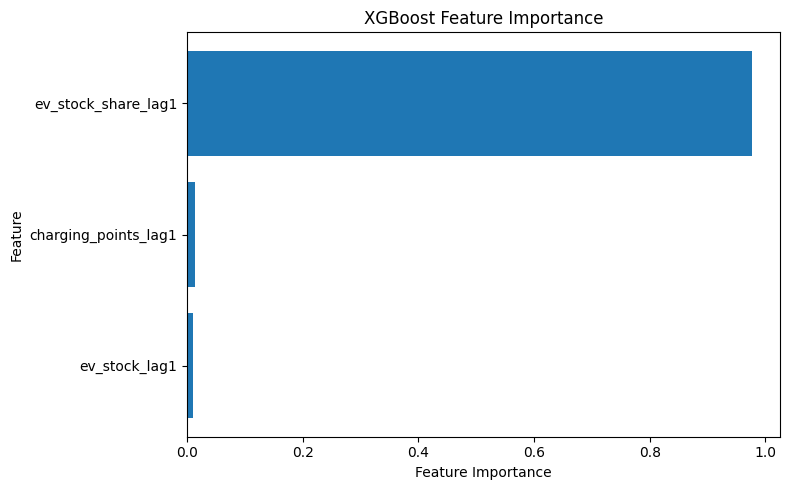

In [13]:
plt.figure(
    figsize=(8, 5)
)


plt.barh(

    xgb_feature_importance[
        "Feature"
    ],

    xgb_feature_importance[
        "Importance"
    ]

)


plt.xlabel(
    "Feature Importance"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "XGBoost Feature Importance"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.show()

In [14]:
print(
    "\nActual EV Sales Share Range:"
)


print(
    y_test.min(),
    "to",
    y_test.max()
)


print(
    "\nXGBoost Prediction Range:"
)


print(
    y_pred_xgb.min(),
    "to",
    y_pred_xgb.max()
)


Actual EV Sales Share Range:
0.22 to 92.0

XGBoost Prediction Range:
0.41005957 to 88.591934


In [15]:
yearly_xgb_results = []


for year in sorted(
    xgb_results["year"].unique()
):

    year_results = xgb_results[
        xgb_results["year"] == year
    ]


    year_actual = year_results[
        "actual_ev_sales_share"
    ]


    year_predicted = year_results[
        "predicted_ev_sales_share"
    ]


    year_r2 = r2_score(
        year_actual,
        year_predicted
    )


    year_mae = mean_absolute_error(
        year_actual,
        year_predicted
    )


    year_rmse = np.sqrt(
        mean_squared_error(
            year_actual,
            year_predicted
        )
    )


    yearly_xgb_results.append({

        "Year": year,

        "R2": year_r2,

        "MAE": year_mae,

        "RMSE": year_rmse

    })


yearly_xgb_performance = pd.DataFrame(
    yearly_xgb_results
)


print(
    "\nXGBoost Performance by Test Year:"
)


print(
    yearly_xgb_performance
)


XGBoost Performance by Test Year:
   Year        R2       MAE       RMSE
0  2023  0.869849  5.871225   7.626734
1  2024  0.561252  9.672420  13.285653


In [16]:
default_model_comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R2": [
        0.3693,
        0.733563,
        xgb_r2
    ],

    "MAE": [
        7.6718,
        7.479407,
        xgb_mae
    ],

    "RMSE": [
        16.3651,
        10.636625,
        xgb_rmse
    ]

})


print(
    "\nDefault Model Performance Comparison:"
)


print(
    default_model_comparison
)


Default Model Performance Comparison:
               Model        R2       MAE       RMSE
0  Linear Regression  0.369300  7.671800  16.365100
1      Random Forest  0.733563  7.479407  10.636625
2            XGBoost  0.723672  7.771822  10.832259


In [18]:
# ============================================================
# XGBOOST HYPERPARAMETER TUNING
# TEMPORAL CROSS-VALIDATION BY YEAR
# ============================================================


# ============================================================
# 17. IMPORT TUNING LIBRARIES
# ============================================================

from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit
)


# ============================================================
# 18. SORT TRAINING DATA BY YEAR
# ============================================================

xgb_train_tuning_df = (
    xgb_train_df
    .sort_values(
        ["year", "country"]
    )
    .reset_index(drop=True)
)


X_train_tuning = xgb_train_tuning_df[
    features
]


y_train_tuning = xgb_train_tuning_df[
    target
]


print(
    "Training data used for XGBoost tuning:"
)


print(
    X_train_tuning.shape
)


print(
    "\nTraining years:"
)


print(
    sorted(
        xgb_train_tuning_df[
            "year"
        ].unique()
    )
)


# ============================================================
# 19. CREATE TEMPORAL CROSS-VALIDATION FOLDS BY YEAR
# ============================================================

training_years = np.array(

    sorted(

        xgb_train_tuning_df[
            "year"
        ].unique()

    )

)


time_split = TimeSeriesSplit(
    n_splits=5
)


temporal_cv_splits = []


for (
    train_year_index,
    validation_year_index
) in time_split.split(
    training_years
):


    cv_train_years = training_years[
        train_year_index
    ]


    cv_validation_years = training_years[
        validation_year_index
    ]


    cv_train_indices = (

        xgb_train_tuning_df.index[

            xgb_train_tuning_df[
                "year"
            ].isin(
                cv_train_years
            )

        ]

        .to_numpy()

    )


    cv_validation_indices = (

        xgb_train_tuning_df.index[

            xgb_train_tuning_df[
                "year"
            ].isin(
                cv_validation_years
            )

        ]

        .to_numpy()

    )


    temporal_cv_splits.append(

        (
            cv_train_indices,
            cv_validation_indices
        )

    )


# ============================================================
# 20. DISPLAY TEMPORAL VALIDATION FOLDS
# ============================================================

print(
    "\nTemporal Cross-Validation Folds:"
)


for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    temporal_cv_splits,
    start=1
):


    fold_train_years = sorted(

        xgb_train_tuning_df

        .iloc[
            train_indices
        ]["year"]

        .unique()

    )


    fold_validation_years = sorted(

        xgb_train_tuning_df

        .iloc[
            validation_indices
        ]["year"]

        .unique()

    )


    print(
        f"\nFold {fold_number}"
    )


    print(
        "Training years  :",
        fold_train_years
    )


    print(
        "Validation years:",
        fold_validation_years
    )


# ============================================================
# 21. DEFINE XGBOOST PARAMETER GRID
# ============================================================

xgb_param_grid = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        2,
        3,
        5
    ],

    "learning_rate": [
        0.01,
        0.05,
        0.1
    ],

    "subsample": [
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.8,
        1.0
    ]

}


# ============================================================
# 22. CREATE XGBOOST MODEL FOR TUNING
# ============================================================

xgb_tuning_model = XGBRegressor(

    random_state=42,

    objective="reg:squarederror",

    n_jobs=1

)


# ============================================================
# 23. CREATE GRID SEARCH
# ============================================================

xgb_grid_search = GridSearchCV(

    estimator=xgb_tuning_model,

    param_grid=xgb_param_grid,

    scoring="neg_root_mean_squared_error",

    cv=temporal_cv_splits,

    n_jobs=-1,

    verbose=1

)


# ============================================================
# 24. RUN XGBOOST HYPERPARAMETER TUNING
# ============================================================

xgb_grid_search.fit(

    X_train_tuning,

    y_train_tuning

)


# ============================================================
# 25. DISPLAY BEST PARAMETERS
# ============================================================

print(
    "\nBest XGBoost Parameters:"
)


print(
    xgb_grid_search.best_params_
)


print(
    "\nBest Temporal Validation RMSE:"
)


print(
    -xgb_grid_search.best_score_
)


# ============================================================
# 26. RETRIEVE BEST XGBOOST MODEL
# ============================================================

best_xgb_model = (

    xgb_grid_search.best_estimator_

)


# ============================================================
# 27. GENERATE FINAL TEST PREDICTIONS
# ============================================================

y_pred_xgb_tuned = (

    best_xgb_model.predict(
        X_test
    )

)


# ============================================================
# 28. EVALUATE TUNED XGBOOST MODEL
# ============================================================

xgb_tuned_r2 = r2_score(

    y_test,

    y_pred_xgb_tuned

)


xgb_tuned_mae = mean_absolute_error(

    y_test,

    y_pred_xgb_tuned

)


xgb_tuned_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        y_pred_xgb_tuned

    )

)


print(
    "\nTuned XGBoost Results"
)


print(
    f"R²   : {xgb_tuned_r2:.4f}"
)


print(
    f"MAE  : {xgb_tuned_mae:.4f}"
)


print(
    f"RMSE : {xgb_tuned_rmse:.4f}"
)


# ============================================================
# 29. COMPARE DEFAULT AND TUNED XGBOOST
# ============================================================

xgb_model_comparison = pd.DataFrame({

    "Model": [
        "Default XGBoost",
        "Tuned XGBoost"
    ],

    "R2": [
        xgb_r2,
        xgb_tuned_r2
    ],

    "MAE": [
        xgb_mae,
        xgb_tuned_mae
    ],

    "RMSE": [
        xgb_rmse,
        xgb_tuned_rmse
    ]

})


print(
    "\nXGBoost Model Comparison:"
)


print(
    xgb_model_comparison
)


# ============================================================
# 30. CREATE TUNED XGBOOST RESULTS DATAFRAME
# ============================================================

xgb_tuned_results = xgb_test_df[
    [
        "country",
        "year"
    ]
].copy()


xgb_tuned_results[
    "actual_ev_sales_share"
] = y_test.values


xgb_tuned_results[
    "predicted_ev_sales_share"
] = y_pred_xgb_tuned


xgb_tuned_results[
    "error"
] = (

    xgb_tuned_results[
        "actual_ev_sales_share"
    ]

    -

    xgb_tuned_results[
        "predicted_ev_sales_share"
    ]

)


xgb_tuned_results[
    "absolute_error"
] = (

    xgb_tuned_results[
        "error"
    ].abs()

)


print(
    "\nLargest Tuned XGBoost Prediction Errors:"
)


print(

    xgb_tuned_results

    .sort_values(
        "absolute_error",
        ascending=False
    )

    .head(10)

)


# ============================================================
# 31. TUNED XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_tuned_feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        best_xgb_model.feature_importances_

})


xgb_tuned_feature_importance = (

    xgb_tuned_feature_importance

    .sort_values(
        "Importance",
        ascending=False
    )

)


print(
    "\nTuned XGBoost Feature Importance:"
)


print(
    xgb_tuned_feature_importance
)


# ============================================================
# 32. CHECK TUNED XGBOOST PREDICTION RANGE
# ============================================================

print(
    "\nActual EV Sales Share Range:"
)


print(
    y_test.min(),
    "to",
    y_test.max()
)


print(
    "\nTuned XGBoost Prediction Range:"
)


print(
    y_pred_xgb_tuned.min(),
    "to",
    y_pred_xgb_tuned.max()
)

Training data used for XGBoost tuning:
(421, 3)

Training years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Temporal Cross-Validation Folds:

Fold 1
Training years  : [np.int64(2011), np.int64(2012)]
Validation years: [np.int64(2013), np.int64(2014)]

Fold 2
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
Validation years: [np.int64(2015), np.int64(2016)]

Fold 3
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Validation years: [np.int64(2017), np.int64(2018)]

Fold 4
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Validation years: [np.int64(2019), np.int64(2020)]

Fold 5
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), n